<a href="https://colab.research.google.com/github/Riz2693/Eksperimen-TensorFlow/blob/main/TensorFlow%20Model%20Creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Muhammad Faris Akbar**
Catatan Pembelaran TensorFlow Lanjutan Custom Model, Callbacks, & Layer

# **Section 1**
## **Inisialisasi Model TensorFlow**
1. Sequential API
2. Functional API
3. Subclassing

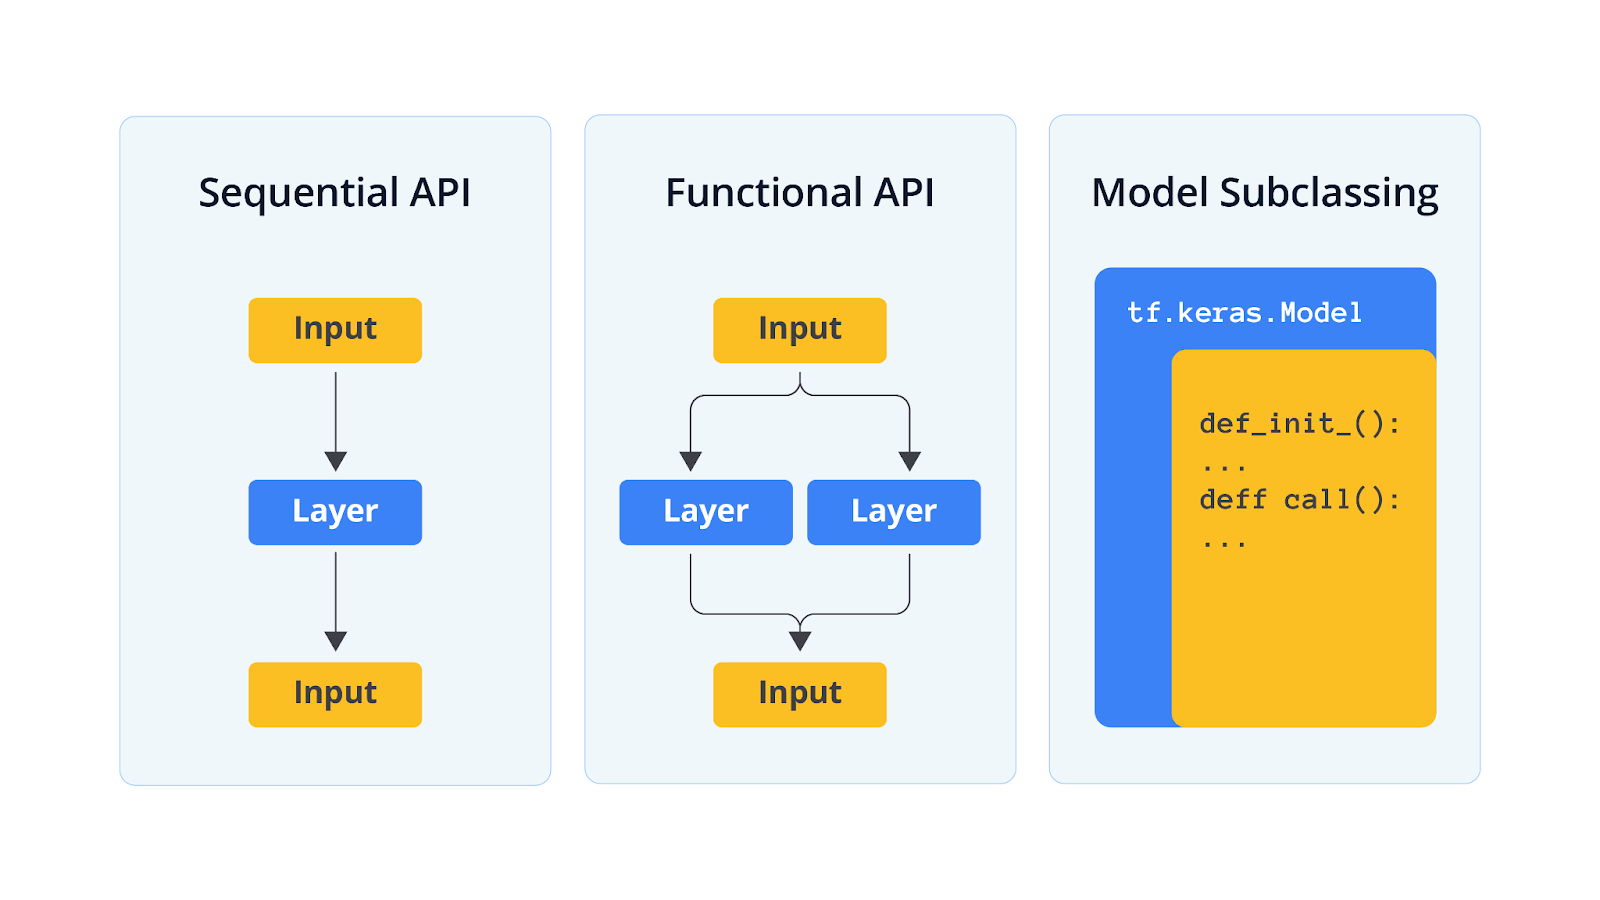

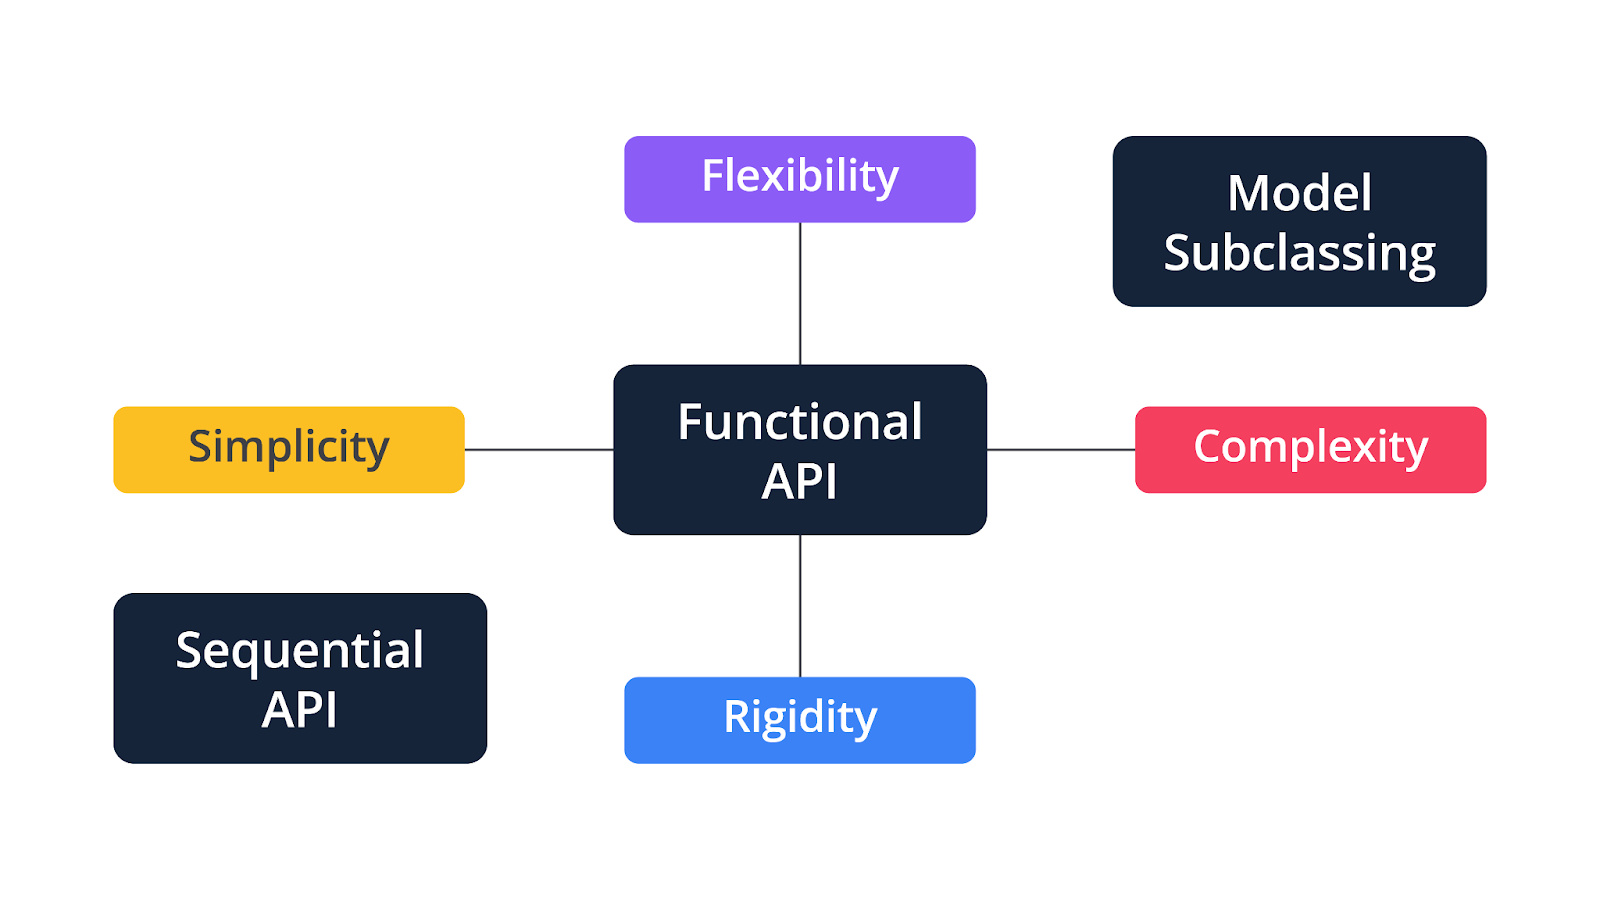

## **Kelebihan dan kekurangan masing-masing pendekatan:**



## **Sequential API**
**Kelebihan**
1. Mudah diimplementasikan
2. Simple dan ringan

**Kekurangan**
1. Keterbatasan pada pengaturan model
2. Hanya bisa mempelajari 1 arah saja (feed forward learning)


In [41]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [42]:
model = Sequential([
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
    ])

## **Functional API**
**Kelebihan**
1. Mudah dikustomisasi
2. Mendukung multi input dan output
3. Fleksibilitas model
4. Mendukung fine tuning dan transfer learning yang beragam
5. Mendukung pembelajaran 2 arah (feed forward dan backpropagation learning) (Bidirectional)

**Kekurangan**
1. Lebih rumit dibandingkan sequential api
2. Keterbatasan dalam menambahkan perilaku custom
3. Kurang cocok untuk arsitektur model yang dinamis

In [43]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

In [44]:
input = Input(shape=(32,))
x = Dense(128, activation='relu')(input)
x = Dense(64, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

In [45]:
model = Model(inputs=input, outputs=output)

## **Subclassing**
**Kelebihan**
1. Flesibilitas penuh (custom model)
2. Mendukung model dinamis
4. Mendukung customisasi model fine tuning dan transfer learning yang lebih beragam
5. Sama seperti functional api mendukung pembelajaran 2 arah (feed forward dan backpropagation learning) (Bidirectional)

**Kekurangan**
1. Lebih rumit dibandingkan sequential api maupun functional api


In [46]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Dense, Input

In [47]:
class MyDenseLayer(Layer):
    def __init__(self, units=32, activation=None):
        super().__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            name="kernel",
            shape=(input_shape[-1], self.units),
            initializer=tf.random_normal_initializer(),
            trainable=True
        )
        self.b = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer=tf.zeros_initializer(),
            trainable=True
        )

    def call(self, inputs):
        return self.activation(tf.matmul(inputs, self.w) + self.b)

# **Section 2**
## **Mengenal apa itu Deep dan Wide Models**

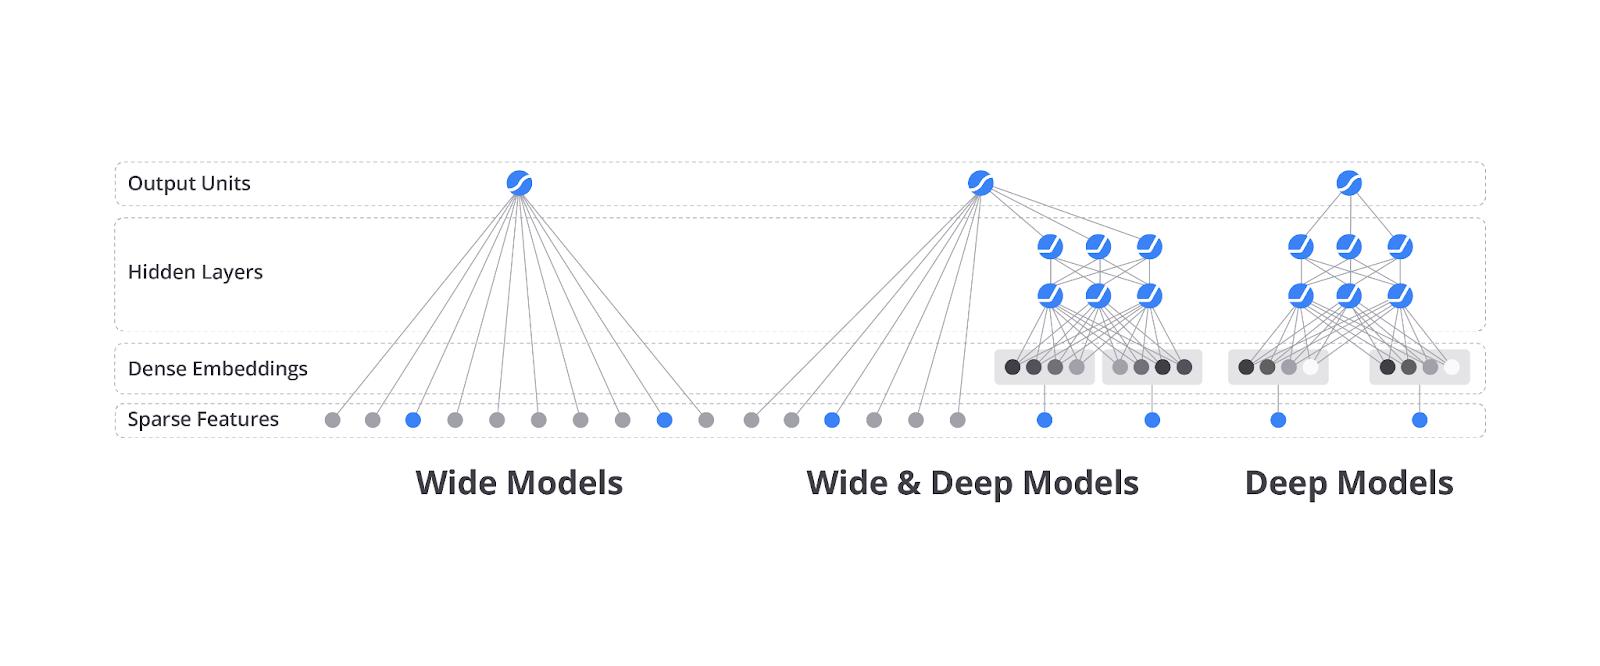

## **Perbandingan Deep dan Wide Models**

*   Deep Path berfungsi untuk mempelajari pola non-linear yang kompleks, ibaratnya seperti seseorang yang memperdalam spesialisasinya di bidang tertentu. Ini biasanya terjadi ketika Anda terus menambahkan beberapa layer ke dalam model deep learning. Jalur ini memungkinkan model untuk menangkap hubungan yang lebih dalam antar fitur dan mengenali pola-pola tersembunyi di dalam data.

*   Wide Path bertugas memproses fitur yang lebih umum dan langsung, seperti hubungan memori asosiasi atau aturan sederhana yang dapat dipelajari tanpa banyak transformasi. Hal ini membantu dalam melihat secara lebih luas fitur yang disediakan.

## **Contoh Penggunaan Deep & Wide Models**

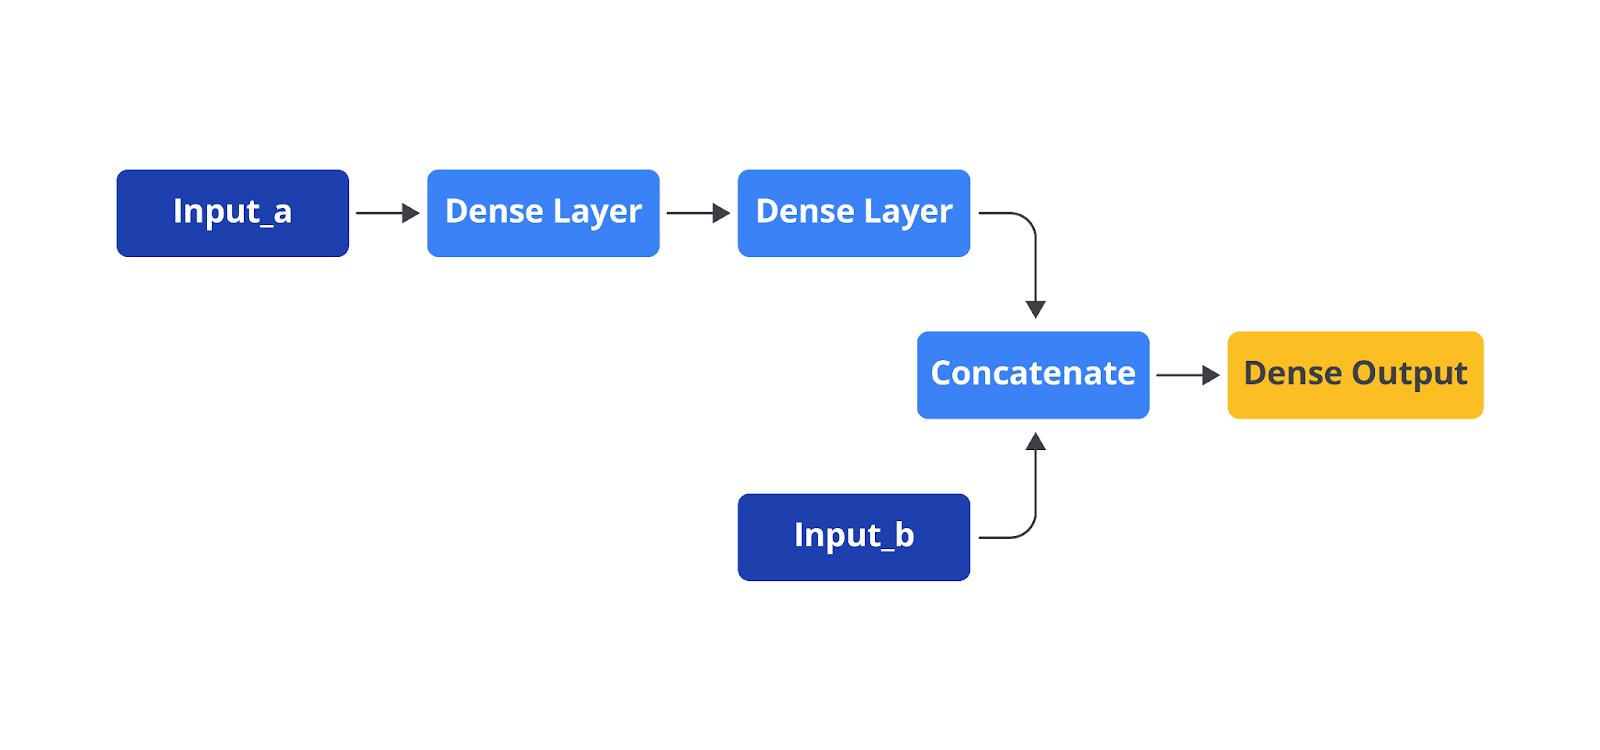

In [48]:
from tensorflow.keras import Model

class DeepAndWideModel(Model):
  def __init__(self, units=32, activation='relu', **kwargs):
    super().__init__(**kwargs)
    self.dense_1 = Dense(units, activation=activation)
    self.dense_2 = Dense(units, activation=activation)
    self.output = Dense(1)

  def call(self, inputs):
    input_a, input_b = inputs
    dense_1 = self.dense_1(input_a)
    dense_2 = self.dense_2(dense_1)
    concat = concatenate([dense_2, input_b])
    output = self.output(concat)

    return output

# **Section 3**
## **Contoh penggunaan subclassing lanjutan untuk custom models**

## **Model residual network (ResNet)**

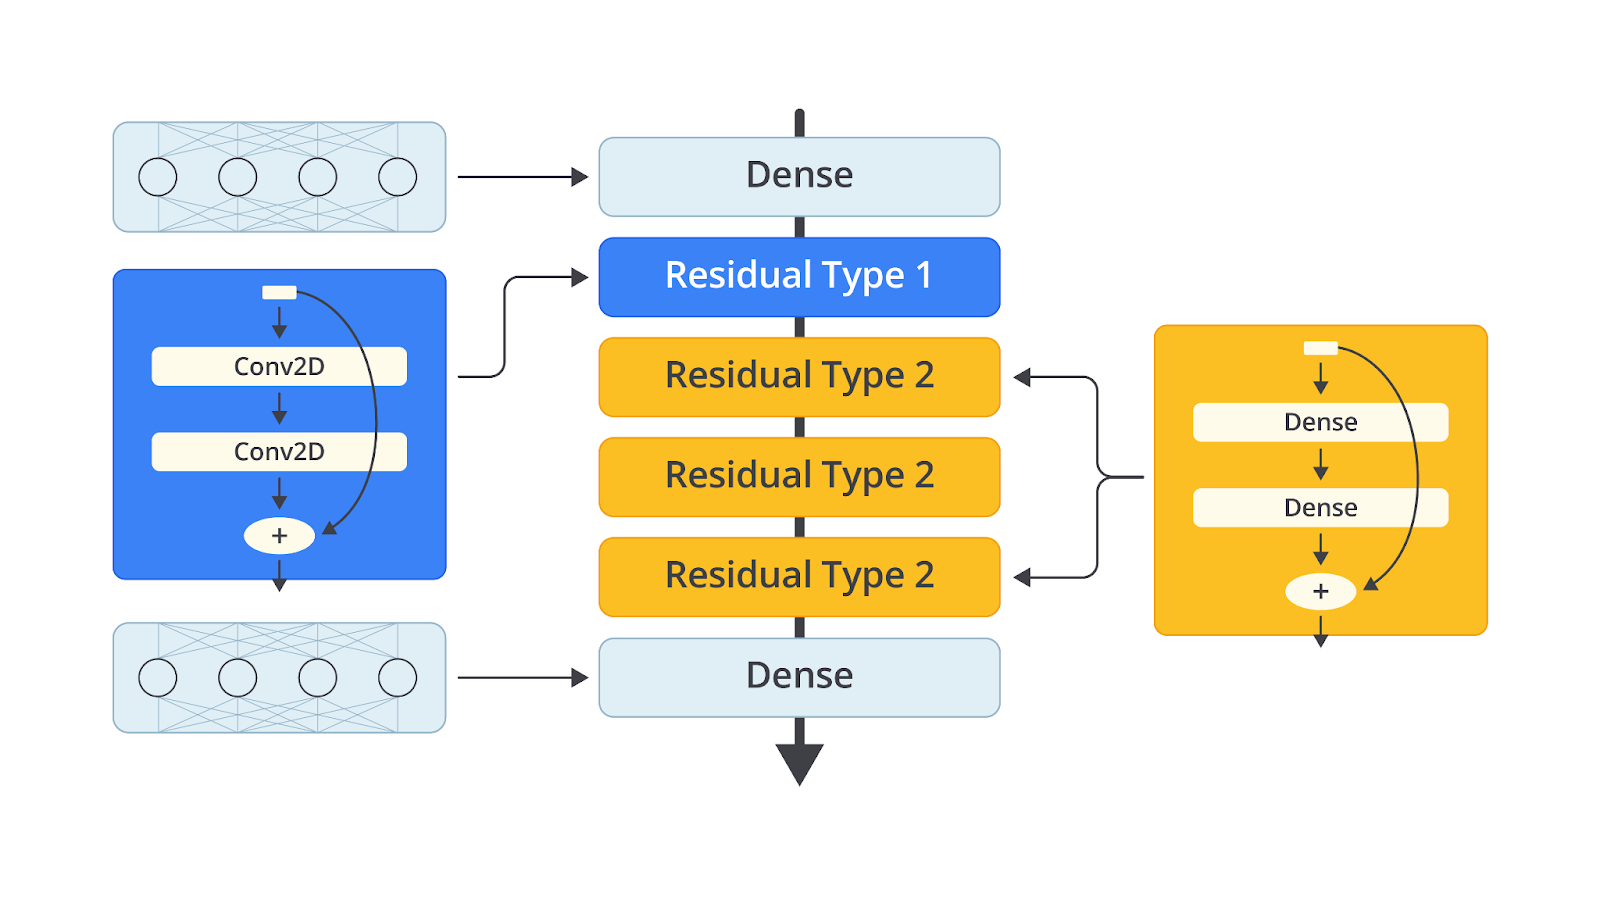

## **Apa itu Residual Network (ResNet)?**
Residual Network (ResNet) merupakan sebuah arsitektur yang sering digunakan dalam tugas computer vision, terutama untuk image classification dan object detection. ResNet adalah arsitektur deep learning yang dibangun dari banyak residual block yang disusun secara berulang dan di dalam setiap residual network ini memiliki mekanisme skip connection.

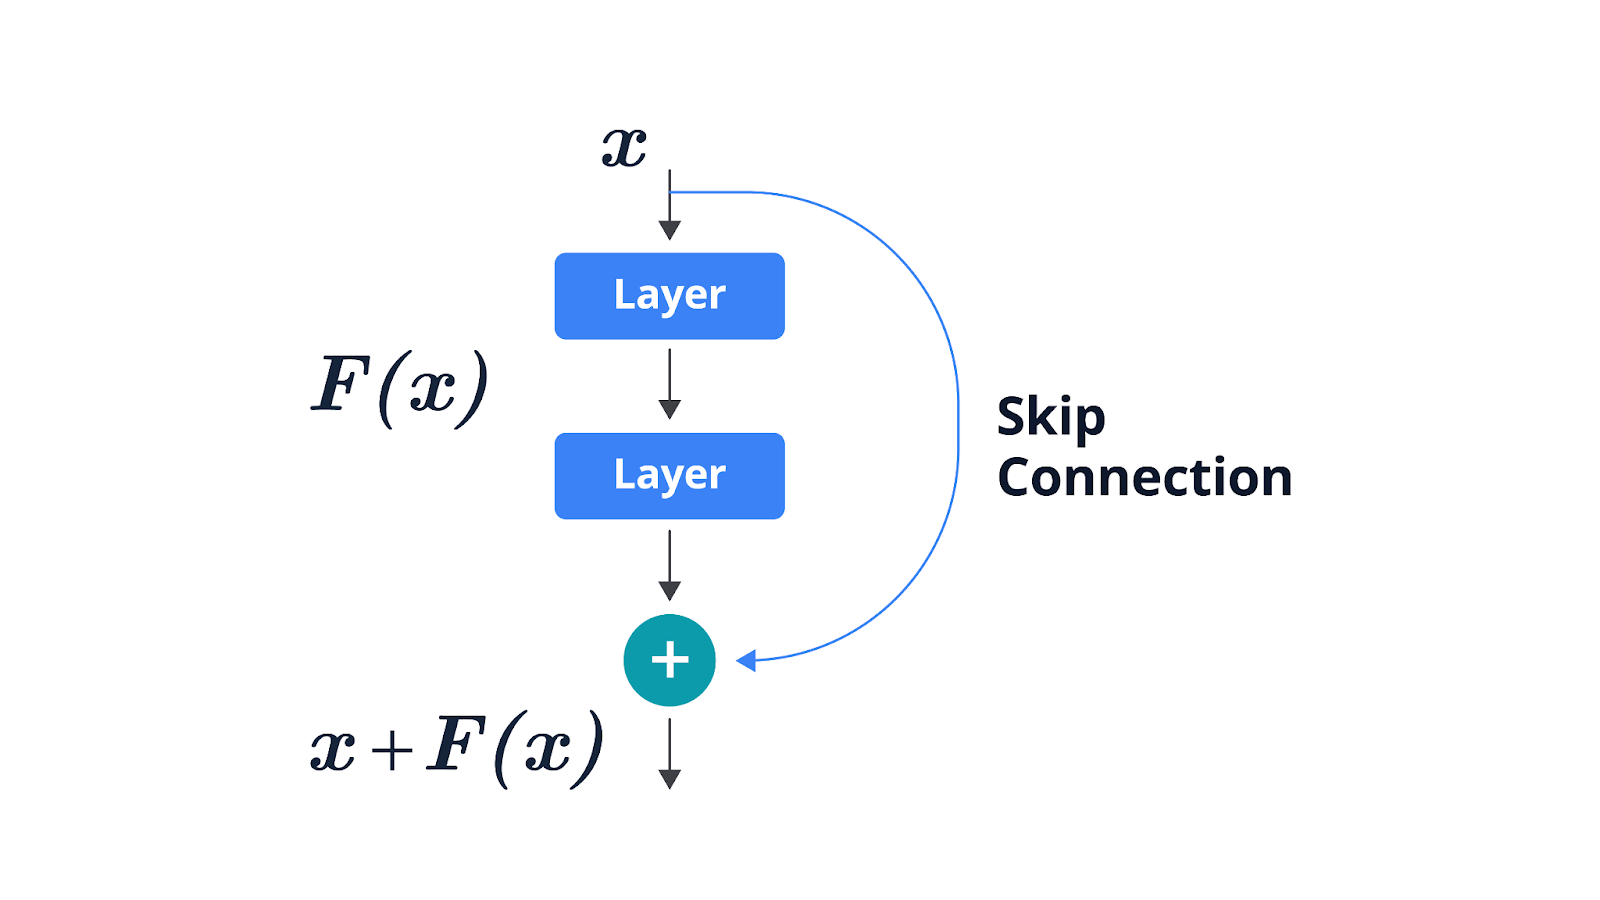

Alih-alih menduplikasi kode secara manual dan membuat tiga blok identik belajar satu per satu, kita dapat menggunakan loop untuk menerapkan residual block sebanyak tiga kali dalam satu arsitektur. Dengan pendekatan ini, kita cukup mendefinisikan satu class Residual Block, lalu memanggilnya dalam loop sebanyak tiga kali ketika akan dieksekusi. Outputnya akan tetap sama tetapi dengan cara implementasi kode yang lebih ringkas.

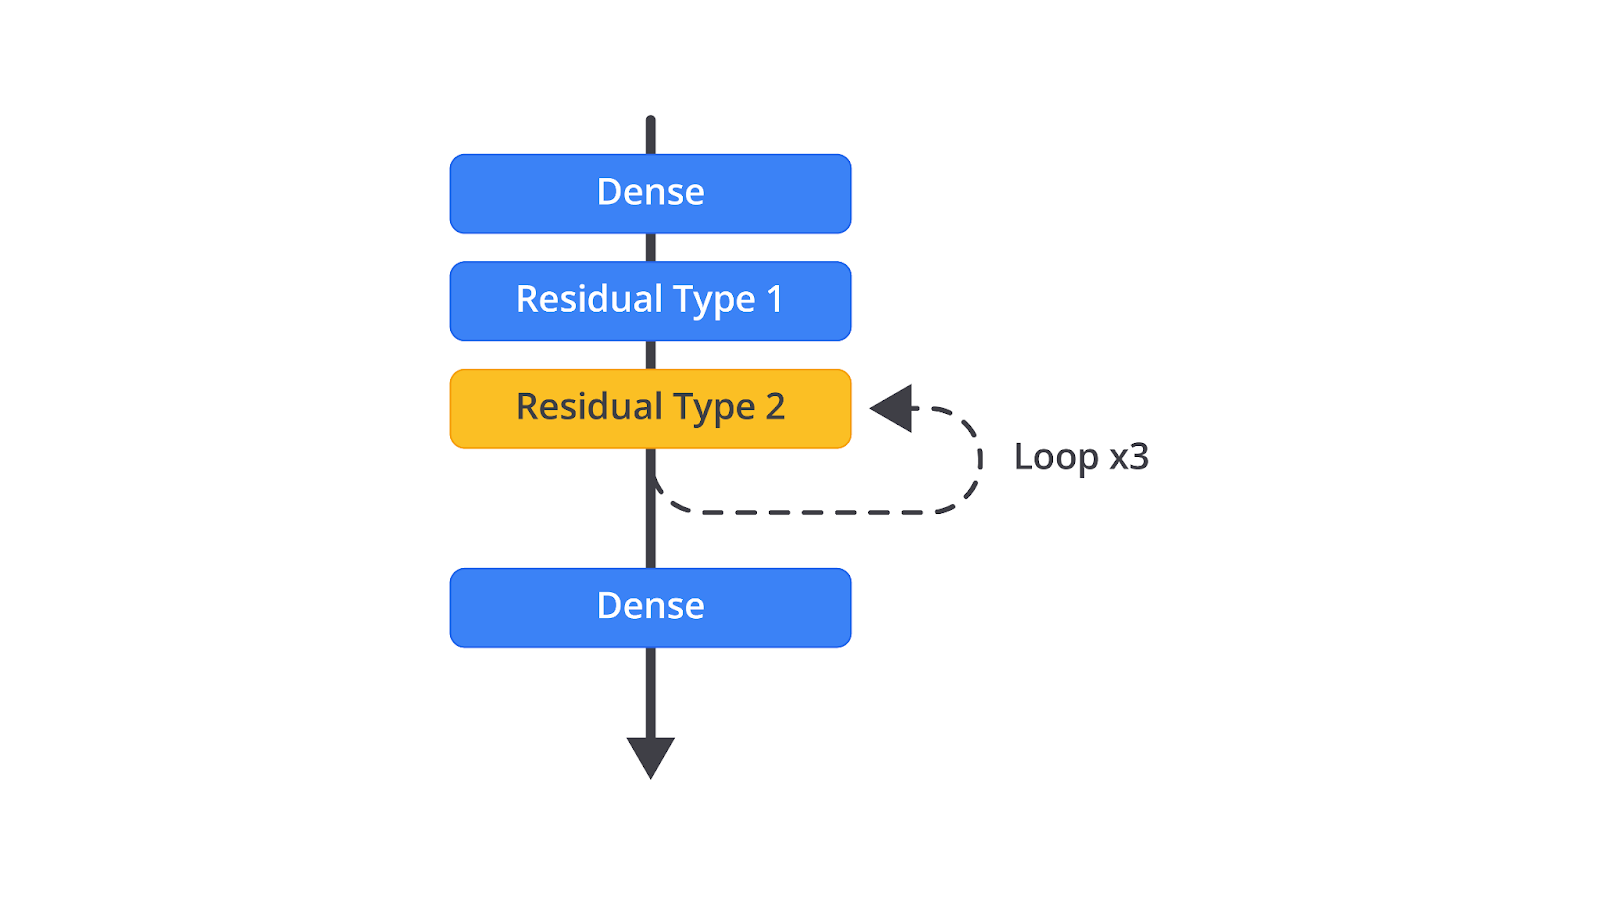

In [49]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Dense, Input, Conv2D

In [50]:
class ResidualType1(Layer):
  def __init__(self, layers, filters, **kwargs):
    super().__init__(**kwargs)
    self.hidden = [Conv2D(filters, (3, 3), padding='same', activation='relu') for _ in range(layers)]

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    return inputs + x

In [51]:
class ResidualType2(Layer):
  def __init__(self, layers, units, **kwargs):
    super().__init__(**kwargs)
    self.hidden = [Dense(units, activation='relu') for _ in range(layers)]

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    return inputs + x

In [52]:
class MyResidual(Model):
  def __init__(self, **kwargs):
    self.hidden = Dense(30, activation='relu')
    self.block1 = ResidualType1(2, 32)
    self.block2 = ResidualType2(2, 64)
    self.out = Dense(1)

  def call(self, inputs):
    x = self.hidden(inputs)
    x = self.block1(x)
    for _ in range(1, 4):
      x = self.block2(x)
    return self.out(x)

# **Contoh Implementasi Lengkap Custom Models**

In [53]:
# !pip install kagglehub

In [54]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LSTM, BatchNormalization
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.losses import Loss
from tensorflow.keras import Model
from tensorflow.keras.optimizers import SGD

In [55]:
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
file_name = 'DailyDelhiClimateTrain.csv'
file_path = os.path.join(path, file_name)

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.


In [56]:
df = pd.read_csv(file_path)
df.head(5)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [57]:
temp = df['meantemp'].values
temp

array([10.        ,  7.4       ,  7.16666667, ..., 14.0952381 ,
       15.05263158, 10.        ])

In [58]:
window_size = 60
batch_size = 100
shuffle_buffer = 1000

In [59]:
def window_dataset(series, window_size, batch_size, shuffle_buffer):
  # Menambahkan 1 dimensi akhir di deret -> (1462,) menjadi (1462, 1)
  series = tf.expand_dims(series, axis=-1)

  # Membuat objek tf.data.Dataset dari deret waktu.
  ds = tf.data.Dataset.from_tensor_slices(series)

  # Kunci dari pembuatan jendela. Menciptakan dataset dari jendela-jendela data.
  # window_size + 1: Setiap jendela akan memiliki ukuran window_size + 1. Angka +1 ini penting karena Anda akan menggunakan window_size elemen sebagai fitur input dan 1 elemen terakhir sebagai target prediksi.
  # shift=1: Menggeser jendela sebanyak 1 langkah ke depan setiap kali, artinya jendela berikutnya dimulai satu elemen setelah jendela sebelumnya (overlap satu elemen).
  # drop_remainder=True: Memastikan bahwa hanya jendela yang memiliki ukuran penuh (window_size + 1) yang akan diambil. Jendela yang tidak lengkap di akhir deret akan dibuang.
  ds = ds.window(window_size + 1, shift=1, drop_remainder=True)

  # flat_map digunakan untuk meratakan dataset dan mengubah setiap objek Dataset (yang merupakan satu jendela) menjadi satu tensor
  ds = ds.flat_map(lambda w: w.batch(window_size + 1))

  # Mengacak urutan jendela-jendela dalam dataset.
  ds = ds.shuffle(shuffle_buffer)

  # Mengubah format setiap jendela. Untuk setiap jendela w:
  # w[:-1]: Mengambil semua elemen kecuali yang terakhir. Ini akan menjadi fitur input (X).
  # w[-1:]: Mengambil elemen terakhir. Ini akan menjadi label target (y).
  ds = ds.map(lambda w: (w[:-1], w[-1:]))

  # batch(batch_size): Mengelompokkan jendela-jendela yang sudah diacak menjadi batch-batch berukuran batch_size.
  # prefetch(1): Mengizinkan dataset untuk melakukan prefetching data, yang berarti ia akan menyiapkan batch data berikutnya saat batch saat ini sedang diproses oleh model.
  return ds.batch(batch_size).prefetch(1)

In [60]:
train_set = window_dataset(temp, window_size, batch_size, shuffle_buffer)

In [61]:
for x, y in train_set.take(1):
  print(x.shape, y.shape)

(100, 60, 1) (100, 1, 1)


In [62]:
class ResidualLSTM(Layer):
  def __init__(self, units):
    super(ResidualLSTM, self).__init__()
    self.lstm = LSTM(units, return_sequences=True)
    self.bn = BatchNormalization()
    self.dense = Dense(units, activation="relu")

  def call(self, inputs):
    x = self.lstm(inputs)
    x = self.bn(x)
    residual = self.dense(inputs)
    return x + residual

In [63]:
class ResidualLSTMModel(Model):
  def __init__(self):
    super(ResidualLSTMModel, self).__init__()
    self.residuallstm1 = ResidualLSTM(60)
    # Menggunakan second residuallstm layer untuk menghindari sharing weight, mengurangi kemungkinan vanishing dan eksploding gradien, serta ekstraksi fitur yang lebih mendalam
    self.residuallstm2 = ResidualLSTM(60)
    self.dense1 = Dense(30, activation='relu')
    self.dense2 = Dense(10, activation='relu')
    self.dense3 = Dense(1)

  def call(self, inputs):
    x = self.residuallstm1(inputs)
    x = self.residuallstm2(x)
    x = self.dense1(x)
    x = self.dense2(x)
    return self.dense3(x)

In [64]:
class CustomHuberLoss(Loss):
  def __init__(self, delta=1.0):
    super(CustomHuberLoss, self).__init__()
    self.delta = delta

  def call(self, y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) <= self.delta
    squared_loss = tf.square(error) / 2
    linear_loss = self.delta * (tf.abs(error) - self.delta / 2)
    return tf.where(is_small_error, squared_loss, linear_loss)

In [69]:
class AdaptiveLearningRateScheduler(Callback):
  def __init__(self, factor=0.5, patience=3, min_lr=1e-6, max_lr=1e-2):
    super(AdaptiveLearningRateScheduler, self).__init__()
    self.factor = factor
    self.patience = patience
    self.min_lr = min_lr
    self.max_lr = max_lr
    self.wait = 0
    self.best_loss = float('inf')

  def on_epoch_end(self, epoch, logs=None):
    current_loss = logs.get('loss')
    lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)

    if current_loss < self.best_loss:
      self.best_loss = current_loss
      self.wait = 0
    else:
      self.wait += 1
      if self.wait >= self.patience:
        new_lr = max(lr * self.factor, self.min_lr)
        self.model.optimizer.learning_rate.assign(new_lr)
        print(f"\nReducing learning rate to {new_lr}")
        self.wait = 0

In [70]:
optimizer = SGD(learning_rate=1.0000e-04, momentum=0.9)

model = ResidualLSTMModel()
model.compile(loss=CustomHuberLoss(delta=0.5), optimizer=optimizer)

lr_callback = AdaptiveLearningRateScheduler()
history = model.fit(train_set, epochs=100, callbacks=[lr_callback])

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 12.9484
Epoch 2/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 11.8304
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 10.9409
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - loss: 9.4386
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - loss: 6.3913
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 2.4590
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 2.0641
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 1.9567
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 1.9214
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - loss: 1.9264
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 1.9173
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 1.9159
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 1.9182
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 1.9114
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - loss: 1.9125
Epoch 16/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/ste

Catatan Pembelaran TensorFlow Lanjutan Custom & Dynamic Training


# **Section 1**

## **Custom Training Loop**

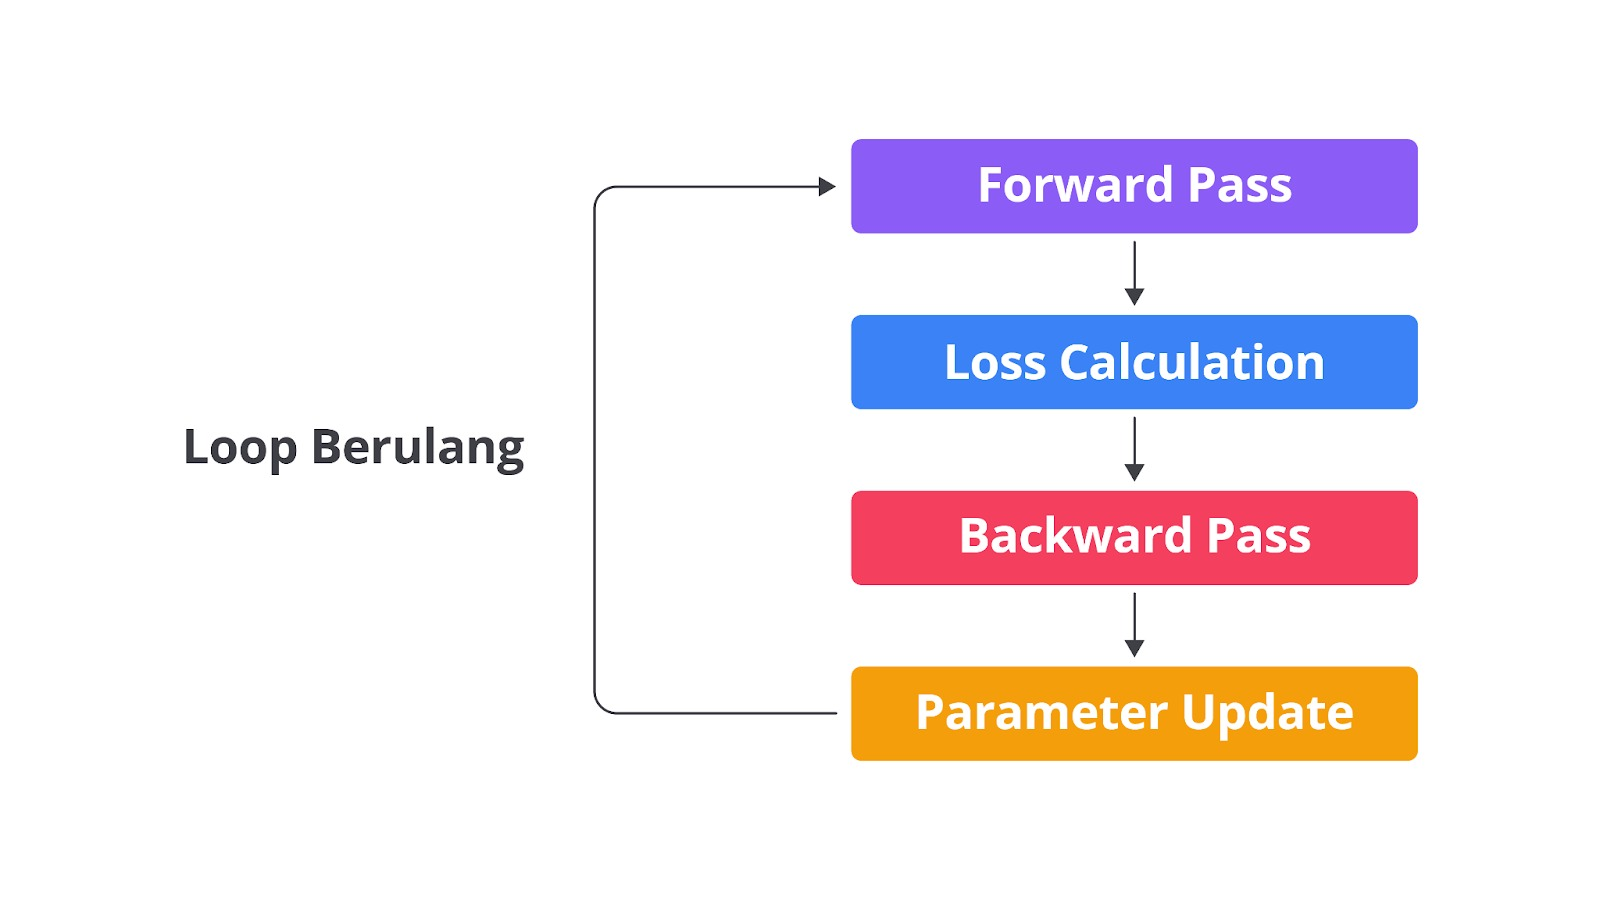

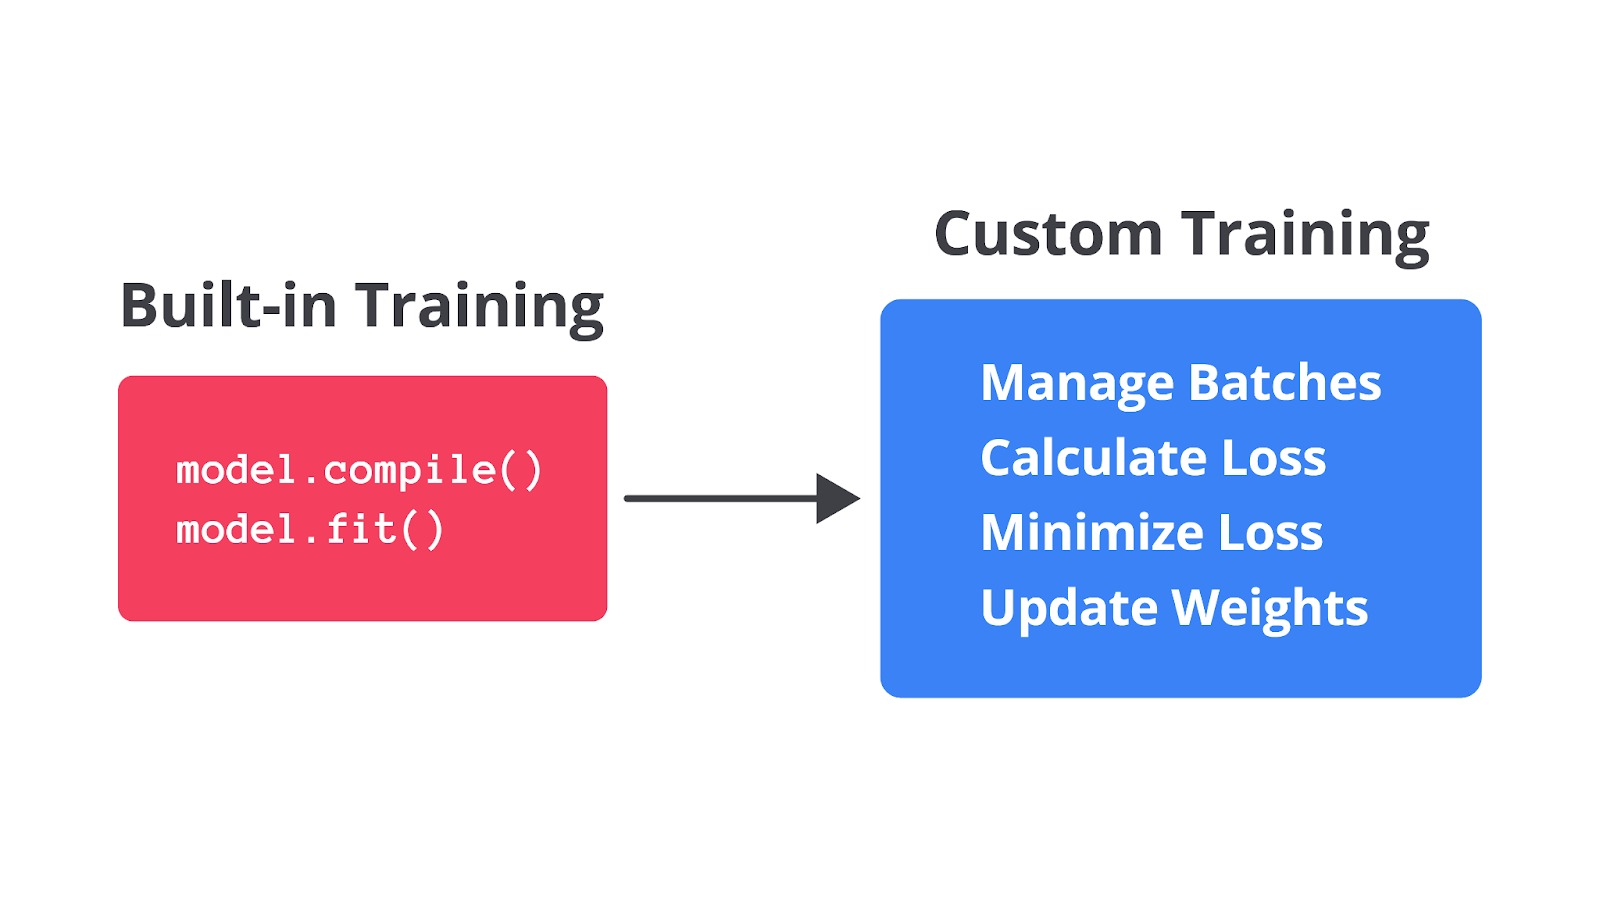

In [ ]:
import tensorflow as tf
import time
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy, Mean

optimizer = Adam()
# Menghitung nilai loss dengan SparseCategoricalCrossentropy
# Memanfaatkan parameter from_logits=True untuk menghitung loss tanpa fungsi aktivasi softmax
loss_fn = SparseCategoricalCrossentropy(from_logits=True)

train_loss_metric = Mean(name='train_loss')
train_accuracy_metric = SparseCategoricalAccuracy(name='train_accuracy')
val_accuracy_metric = SparseCategoricalAccuracy(name='val_accuracy')

In [ ]:
def apply_gradients(model, x_batch, y_batch, loss_fn, optimizer):
  #  Model mencatat gradien berdasarkan persamaan yang disimpan di tf.GradientTape()
  with tf.GradientTape() as tape:
      predictions = model(x_batch, training=True)
      loss = loss_fn(y_batch, predictions)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  train_loss_metric.update_state(loss)
  train_accuracy_metric.update_state(y_batch, predictions)

In [ ]:
def train_one_epoch(model, dataset, loss_fn, optimizer):
  for x_batch, y_batch in dataset:
    apply_gradients(model, x_batch, y_batch, loss_fn, optimizer)

  return train_loss_metric.result().numpy(), train_accuracy_metric.result().numpy()

In [ ]:
def val_step(model, val_dataset):
  for x_batch, y_batch in val_dataset:
    predictions = model(x_batch, training=False)
    val_accuracy_metric.update_state(y_batch, predictions)

  return val_accuracy_metric.result().numpy()

In [ ]:
def train(model, train_dataset, val_dataset, loss_fn, optimizer, epochs=10):
  for epoch in range(epochs):
    start_time = time.time()
    train_loss_metric.reset_state()
    train_accuracy_metric.reset_state()
    val_accuracy_metric.reset_state()

    train_loss, train_acc = train_one_epoch(model, train_dataset, loss_fn, optimizer)
    val_acc = val_step(model, val_dataset)
    duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs} - {duration:.2f}s - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_acc: {val_acc:.4f}")

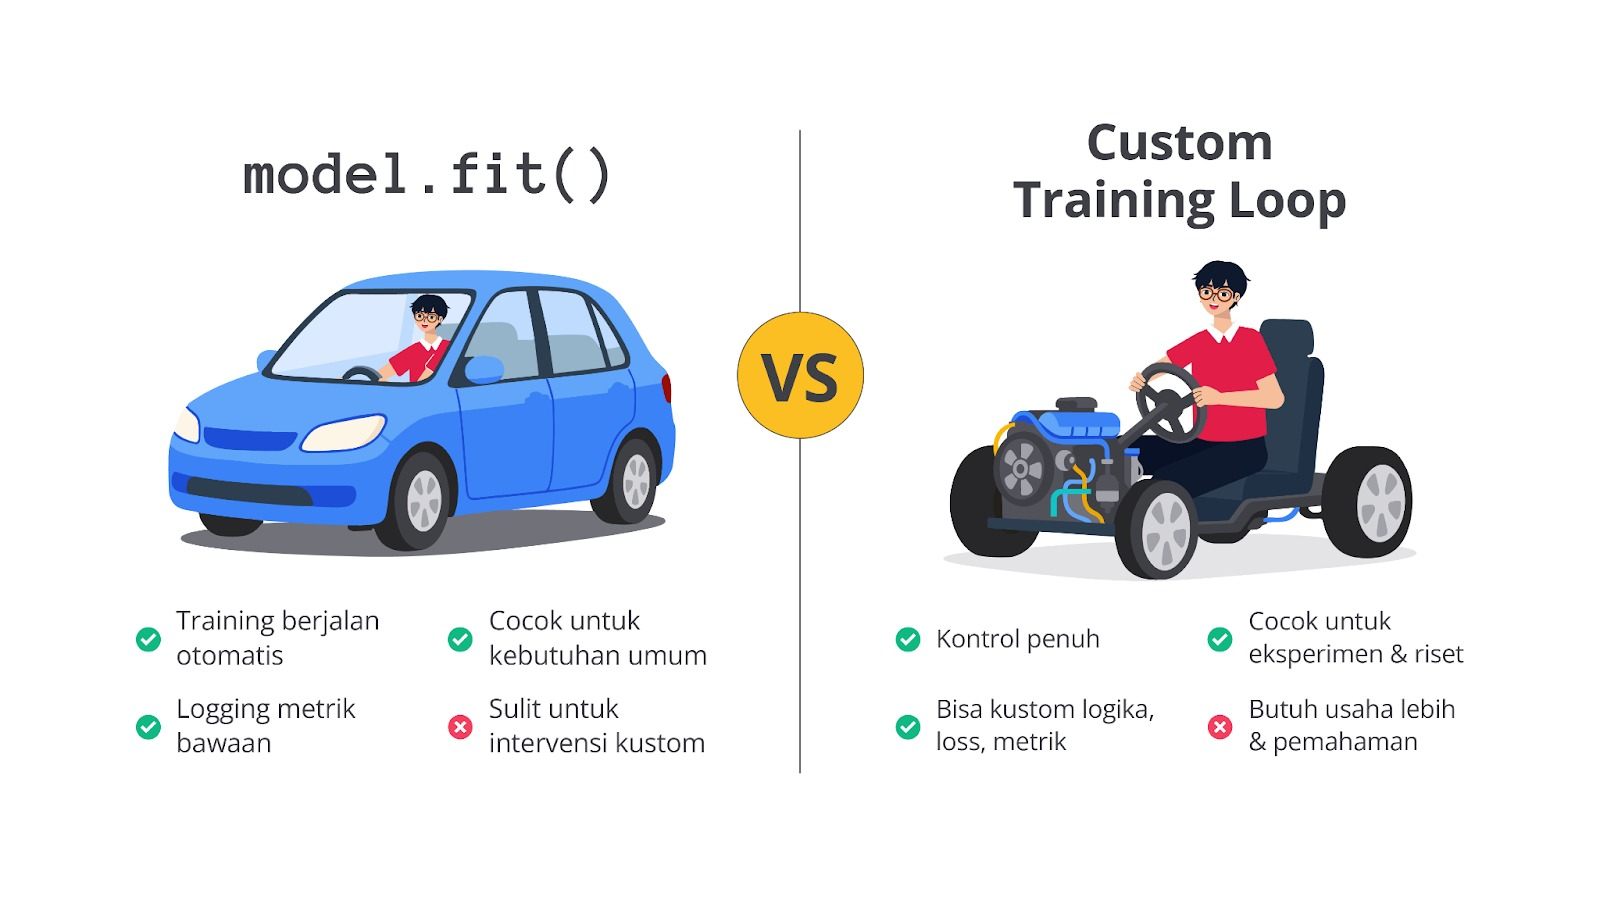

## **Dynamic Training**

# **Catatan Tambahan (Eksperimen)**



1.   TensorFlow/Keras mengharapkan input dalam format (batch_size, fitur)



In [ ]:
# import tensorflow as tf
# from tensorflow.keras.layers import Dense

# # 1. Buat layer baru
# layer = Dense(10)

# # Cek apakah sudah ada bobot? (Pasti kosong/Error jika diakses langsung)
# print(f"Jumlah bobot setelah inisialisasi: {len(layer.weights)}")
# # print(f"Ukuran kernel (weights): {layer.kernel.shape}")
# # print(f"Ukuran bias: {layer.bias.shape}")

# # 2. Panggil layer dengan input dummy
# # Di sinilah proses 'Build' terjadi secara otomatis
# input_dummy = tf.ones((1, 5)) # Batch size 1, input dimension 5
# print(input_dummy)
# _ = layer(input_dummy)

# print(f"Jumlah bobot setelah call pertama: {len(layer.weights)}")
# print(f"Ukuran kernel (weights): {layer.kernel}")
# print(f"Ukuran bias: {layer.bias}")

In [ ]:
# # Mari kita lihat isi bobotnya
# # Keras secara default menggunakan 'Glorot Uniform' untuk kernel
# # dan 'Zeros' untuk bias saat pertama kali dibuat.
# print("Isi Bobot Kernel (Awal):")
# display(layer.kernel.numpy()[:2, :2]) # Tampilkan sedikit saja

# print("\nIsi Bias (Awal):")
# display(layer.bias.numpy())

In [ ]:
# import numpy as np
# import tensorflow as tf

# # Simulasi manual apa yang terjadi di dalam Dense Layer
# # Misal input kita 3 fitur, dan kita ingin output 2 unit
# input_data = np.array([[1.0, 2.0, 3.0]], dtype='float32')

# # Dense(2) akan menciptakan:
# # Weight: matriks 3x2
# weights = np.array([[0.1, 0.2],
#                     [0.3, 0.4],
#                     [0.5, 0.6]], dtype='float32')

# # Bias: vektor 2
# bias = np.array([0.01, 0.02], dtype='float32')

# # RUMUS: (Input * Weight) + Bias
# dot_product = np.dot(input_data, weights)
# output = dot_product + bias

# print("1. Input Data (1x3):", input_data)
# print("2. Weights (3x2):\n", weights)
# print("3. Hasil Perkalian (1x2):", dot_product)
# print("4. Hasil Akhir (+Bias):", output)

In [ ]:
# # Contoh bagaimana TensorFlow melihat 'kontribusi kesalahan' (Gradient)
# x = tf.Variable(3.0) # Misal bobot awal

# with tf.GradientTape() as tape:
#     # Misal fungsi Loss kita adalah y = x^2
#     y = x**2

# # Turunan dari x^2 adalah 2x.
# # Jika x=3, maka gradiennya harus 6
# gradient = tape.gradient(y, x)
# print(f"Jika bobot = {x.numpy()}, maka arah perubahan (gradien) = {gradient.numpy()}")
# print("Optimizer akan menggeser bobot berlawanan arah dengan gradien ini.")

In [6]:
# import tensorflow as tf

# # Misal ini adalah output mentah dari layer Dense terakhir (Logits)
# logits = tf.constant([[2.0, 1.0, 0.1]])

# # Jika kita ingin melihat probabilitasnya (biasanya untuk interpretasi manusia)
# probabilities = tf.nn.softmax(logits)

# print("1. Logits (Mentah):", logits.numpy())
# print("2. Probabilities (Setelah Softmax):", probabilities.numpy())
# print("   (Total probabilitas selalu 1.0)")

# # Demonstrasi Loss
# y_true = tf.constant([0]) # Target kelas indeks 0

# # Cara yang direkomendasikan (from_logits=True)
# loss_logits = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# print("\nLoss menggunakan Logits:", loss_logits(y_true, logits).numpy())

# # Cara lama (from_logits=False)
# loss_probs = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
# print("Loss menggunakan Probabilitas:", loss_probs(y_true, probabilities).numpy())

1. Logits (Mentah): [[2.  1.  0.1]]
2. Probabilities (Setelah Softmax): [[0.6590012  0.24243298 0.09856589]]
   (Total probabilitas selalu 1.0)

Loss menggunakan Logits: 0.41702995
Loss menggunakan Probabilitas: 0.41702995


In [9]:
# import tensorflow as tf

# # Kasus Biner: Misal model mengeluarkan angka 10.0 (Logit)
# binary_logit = tf.constant([[10.0]])
# y_true = tf.constant([[1.0]]) # Target kelas 1

# # 1. Cara Stabil (Direkomendasikan)
# bce_logits = tf.keras.losses.BinaryCrossentropy(from_logits=True)
# loss_stable = bce_logits(y_true, binary_logit)

# # 2. Cara Manual (Sigmoid dulu baru Loss)
# prob = tf.math.sigmoid(binary_logit)
# bce_probs = tf.keras.losses.BinaryCrossentropy(from_logits=False)
# loss_manual = bce_probs(y_true, prob)

# print(f"Logit Biner: {binary_logit.numpy()[0][0]}")
# print(f"Probabilitas (Sigmoid): {prob.numpy()[0][0]}")
# print(f"Loss (from_logits=True):  {loss_stable.numpy()}")
# print(f"Loss (from_logits=False): {loss_manual.numpy()}")

Logit Biner: 10.0
Probabilitas (Sigmoid): 0.9999545812606812
Loss (from_logits=True):  4.5398901420412585e-05
Loss (from_logits=False): 4.541977250482887e-05


In [16]:
# # Bukti ketidakstabilan pada angka ekstrem di Sigmoid
# extreme_binary_logit = tf.constant([[100.0]])

# # Sigmoid dari 100 sangat mendekati 1.0 sampai komputer menganggapnya persis 1.0
# prob_extreme = tf.math.sigmoid(extreme_binary_logit)

# # Jika targetnya adalah 0 (sangat salah), Loss harusnya sangat besar
# y_wrong = tf.constant([[0.0]])

# loss_t = tf.keras.losses.BinaryCrossentropy(from_logits=True)(y_wrong, extreme_binary_logit)
# loss_f = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_wrong, prob_extreme)

# print(f"Logit: {extreme_binary_logit.numpy()[0][0]}")
# print(f"Loss (Stable): {loss_t.numpy()}")
# print(f"Loss (Unstable): {loss_f.numpy()} <-- Seringkali mentok di batas tertentu (clipping)")

Logit: 100.0
Loss (Stable): 100.0
Loss (Unstable): 15.942384719848633 <-- Seringkali mentok di batas tertentu (clipping)


In [15]:
# import tensorflow as tf

# # Rank 1: Vektor (Hanya 1 dimensi)
# tensor_r1 = tf.constant([100.0])

# # Rank 2: Matriks (Biasanya untuk Batch)
# tensor_r2 = tf.constant([[100.0]])

# print(f"Tensor R1 (1 kurung): Shape={tensor_r1.shape}, Rank={tf.rank(tensor_r1).numpy()}")
# print(f"Tensor R2 (2 kurung): Shape={tensor_r2.shape}, Rank={tf.rank(tensor_r2).numpy()}")

# # Contoh kenapa butuh [[ ]] di Loss Function
# y_true = tf.constant([[0]]) # 1 label dalam batch
# y_pred = tf.constant([[0.9]]) # 1 prediksi dalam batch

# loss = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
# print(f"\nLoss berhasil dihitung karena shape cocok: {loss.numpy()}")

Tensor R1 (1 kurung): Shape=(1,), Rank=1
Tensor R2 (2 kurung): Shape=(1, 1), Rank=2

Loss berhasil dihitung karena shape cocok: 2.3025848865509033


In [7]:
# import tensorflow as tf
# import numpy as np

# # Simulasikan output model yang sangat ekstrem (Logits)
# extreme_logits = tf.constant([[100.0, -100.0, 0.0]])
# y_true = tf.constant([0])

# print(f"Logits Ekstrem: {extreme_logits.numpy()}")

# # --- SKENARIO 1: from_logits=False (Manual Softmax) ---
# # Softmax dari 100 akan menghasilkan e^100 yang sangat besar
# probs = tf.nn.softmax(extreme_logits)
# loss_unstable = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

# # --- SKENARIO 2: from_logits=True (Internal Handling) ---
# loss_stable = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# print(f"\nProbabilitas (Manual Softmax): {probs.numpy()}")
# print(f"Loss (from_logits=False): {loss_unstable(y_true, probs).numpy()}")
# print(f"Loss (from_logits=True):  {loss_stable(y_true, extreme_logits).numpy()}")

Logits Ekstrem: [[ 100. -100.    0.]]

Probabilitas (Manual Softmax): [[1. 0. 0.]]
Loss (from_logits=False): 2.3841855067985307e-07
Loss (from_logits=True):  0.0


In [8]:
# # Mari kita coba angka yang LEBIH ekstrem lagi untuk memicu NaN
# super_extreme_logits = tf.constant([[1000.0, 0.0, 0.0]])

# probs_nan = tf.nn.softmax(super_extreme_logits)
# loss_f = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)(y_true, probs_nan)
# loss_t = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)(y_true, super_extreme_logits)

# print(f"Logits: {super_extreme_logits.numpy()}")
# print(f"Loss (from_logits=False): {loss_f.numpy()}  <-- Berisiko NaN atau tidak akurat")
# print(f"Loss (from_logits=True):  {loss_t.numpy()}  <-- Tetap Stabil")

Logits: [[1000.    0.    0.]]
Loss (from_logits=False): 2.3841855067985307e-07  <-- Berisiko NaN atau tidak akurat
Loss (from_logits=True):  0.0  <-- Tetap Stabil
